In [42]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings 
warnings.filterwarnings('ignore')

In [43]:
df=pd.read_csv(r"C:\Users\GCE PMNA\Downloads\GlobalTemperatures.csv")
df.head()

,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
df.shape

(3192, 9)

In [45]:
df.columns


Index(['dt', 'LandAverageTemperature', 'LandAverageTemperatureUncertainty',
       'LandMaxTemperature', 'LandMaxTemperatureUncertainty',
       'LandMinTemperature', 'LandMinTemperatureUncertainty',
       'LandAndOceanAverageTemperature',
       'LandAndOceanAverageTemperatureUncertainty'],
      dtype='object')

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3192 entries, 0 to 3191
Data columns (total 9 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   dt                                         3192 non-null   object 
 1   LandAverageTemperature                     3180 non-null   float64
 2   LandAverageTemperatureUncertainty          3180 non-null   float64
 3   LandMaxTemperature                         1992 non-null   float64
 4   LandMaxTemperatureUncertainty              1992 non-null   float64
 5   LandMinTemperature                         1992 non-null   float64
 6   LandMinTemperatureUncertainty              1992 non-null   float64
 7   LandAndOceanAverageTemperature             1992 non-null   float64
 8   LandAndOceanAverageTemperatureUncertainty  1992 non-null   float64
dtypes: float64(8), object(1)
memory usage: 224.6+ KB


In [47]:
df.describe()

,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
count,3180.000000,3180.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000
mean,8.374731,0.938468,14.350601,0.479782,2.743595,0.431849,15.212566,0.128532
std,4.381310,1.096440,4.309579,0.583203,4.155835,0.445838,1.274093,0.073587
min,-2.080000,0.034000,5.900000,0.044000,-5.407000,0.045000,12.475000,0.042000
25%,4.312000,0.186750,10.212000,0.142000,-1.334500,0.155000,14.047000,0.063000
50%,8.610500,0.392000,14.760000,0.252000,2.949500,0.279000,15.251000,0.122000
75%,12.548250,1.419250,18.451500,0.539000,6.778750,0.458250,16.396250,0.151000
max,19.021000,7.880000,21.320000,4.373000,9.715000,3.498000,17.611000,0.457000


In [48]:

df.describe(include='object')

,dt
count,3192
unique,3192
top,1750-01-01
freq,1


In [49]:
df.isna().sum()

dt                                              0
LandAverageTemperature                         12
LandAverageTemperatureUncertainty              12
LandMaxTemperature                           1200
LandMaxTemperatureUncertainty                1200
LandMinTemperature                           1200
LandMinTemperatureUncertainty                1200
LandAndOceanAverageTemperature               1200
LandAndOceanAverageTemperatureUncertainty    1200
dtype: int64

In [50]:

df_ffill = df.fillna(method='ffill')
df_clean = df_ffill.fillna(method='bfill')
df=df_clean

In [51]:
df.isna().sum()

dt                                           0
LandAverageTemperature                       0
LandAverageTemperatureUncertainty            0
LandMaxTemperature                           0
LandMaxTemperatureUncertainty                0
LandMinTemperature                           0
LandMinTemperatureUncertainty                0
LandAndOceanAverageTemperature               0
LandAndOceanAverageTemperatureUncertainty    0
dtype: int64

In [52]:
num_col=(df.select_dtypes('number'))
num_col

,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,3.034,3.574,8.242,1.738,-3.206,2.822,12.833,0.367
1,3.083,3.702,8.242,1.738,-3.206,2.822,12.833,0.367
2,5.626,3.076,8.242,1.738,-3.206,2.822,12.833,0.367
3,8.490,2.451,8.242,1.738,-3.206,2.822,12.833,0.367
4,11.573,2.072,8.242,1.738,-3.206,2.822,12.833,0.367
...,...,...,...,...,...,...,...,...
3187,14.755,0.072,20.699,0.110,9.005,0.170,17.589,0.057
3188,12.999,0.079,18.845,0.088,7.199,0.229,17.049,0.058
3189,10.801,0.102,16.450,0.059,5.232,0.115,16.290,0.062
3190,7.433,0.119,12.892,0.093,2.157,0.106,15.252,0.063


In [53]:
datadict=pd.DataFrame(df.dtypes)
datadict['MissingVal'] =df.isnull().sum()
datadict['NUnique']=df.nunique()
datadict['Count']=df.count()
datadict = datadict.rename(columns={0:'DataType'})
datadict

,DataType,MissingVal,NUnique,Count
dt,object,0,3192,3192
LandAverageTemperature,float64,0,2839,3192
LandAverageTemperatureUncertainty,float64,0,1594,3192
LandMaxTemperature,float64,0,1814,3192
LandMaxTemperatureUncertainty,float64,0,841,3192
LandMinTemperature,float64,0,1873,3192
LandMinTemperatureUncertainty,float64,0,781,3192
LandAndOceanAverageTemperature,float64,0,1596,3192
LandAndOceanAverageTemperatureUncertainty,float64,0,294,3192


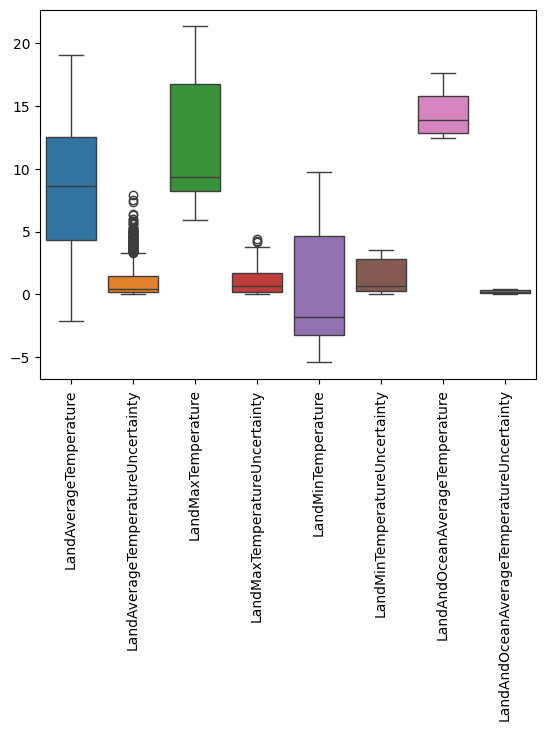

In [54]:
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

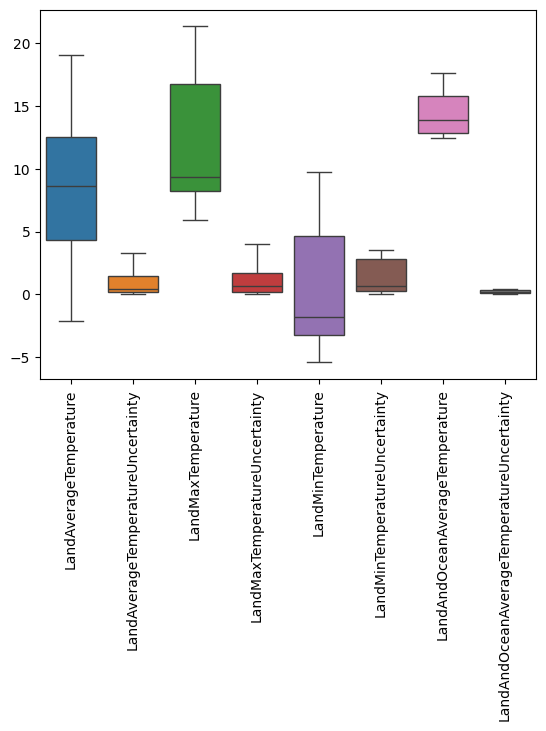

In [55]:
Q1=df['LandAverageTemperatureUncertainty'].quantile(.25)
Q3=df['LandAverageTemperatureUncertainty'].quantile(.75)
IQR=Q3-Q1
l_limit=Q1-1.5*IQR
u_limit=Q3+1.5*IQR
df['LandAverageTemperatureUncertainty']=df['LandAverageTemperatureUncertainty'].clip(l_limit,u_limit)
Q1=df['LandMaxTemperatureUncertainty'].quantile(.25)
Q3=df['LandMaxTemperatureUncertainty'].quantile(.75)
IQR=Q3-Q1
l_limit=Q1-1.5*IQR
u_limit=Q3+1.5*IQR
df['LandMaxTemperatureUncertainty']=df['LandMaxTemperatureUncertainty'].clip(l_limit,u_limit)
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

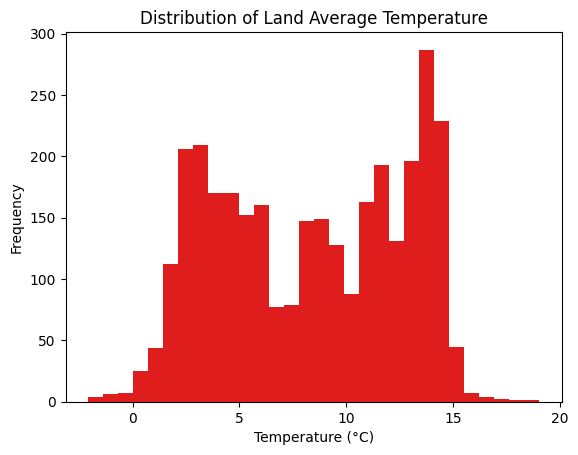

In [56]:
plt.hist(df['LandAverageTemperature'],color="#E01D1D", bins=30)
plt.title("Distribution of Land Average Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

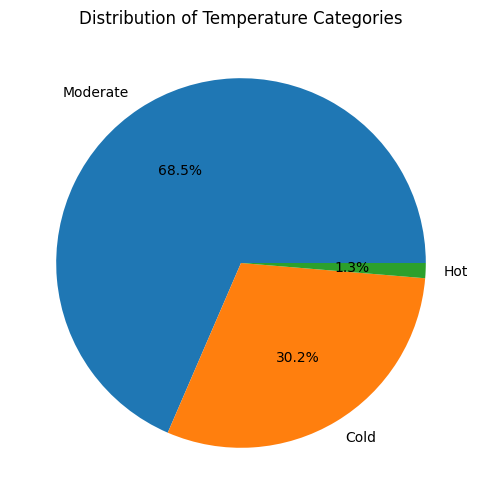

In [57]:
bins = [-50, 5, 15, 50]
labels = ['Cold', 'Moderate', 'Hot']

df['Temp_Category'] = pd.cut(
    df['LandAverageTemperature'],
    bins=bins,
    labels=labels
)

plt.figure(figsize=(6,6))
df['Temp_Category'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Distribution of Temperature Categories")
plt.ylabel("")
plt.show()

In [58]:
df=df.drop(['Temp_Category'],axis=1)

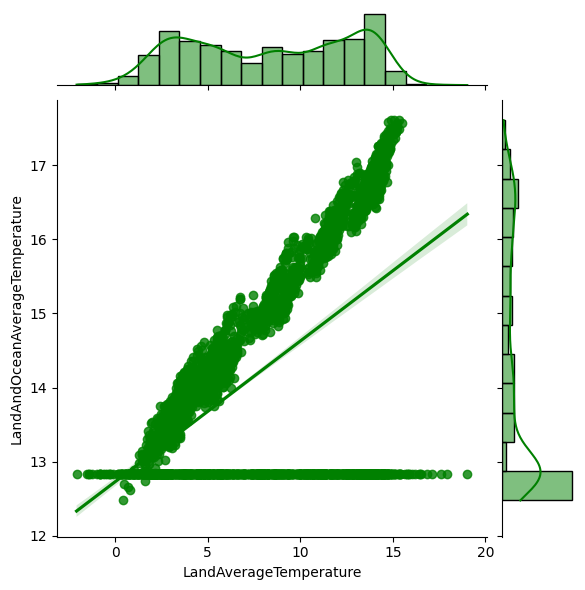

In [59]:
sns.jointplot(data=df, x='LandAverageTemperature', y='LandAndOceanAverageTemperature',kind='reg', color='g')
plt.show()

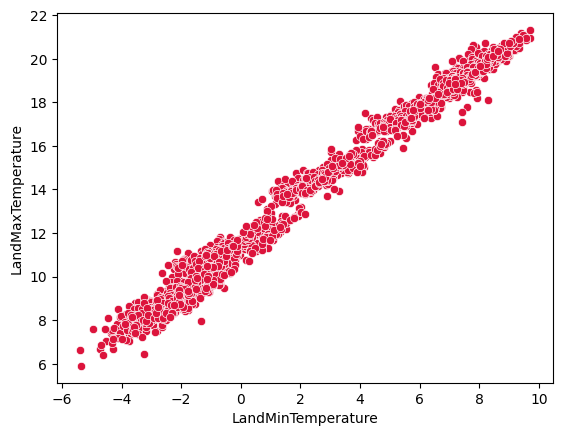

In [60]:
sns.scatterplot(x='LandMinTemperature', y='LandMaxTemperature', data=df, color='crimson')
plt.show()


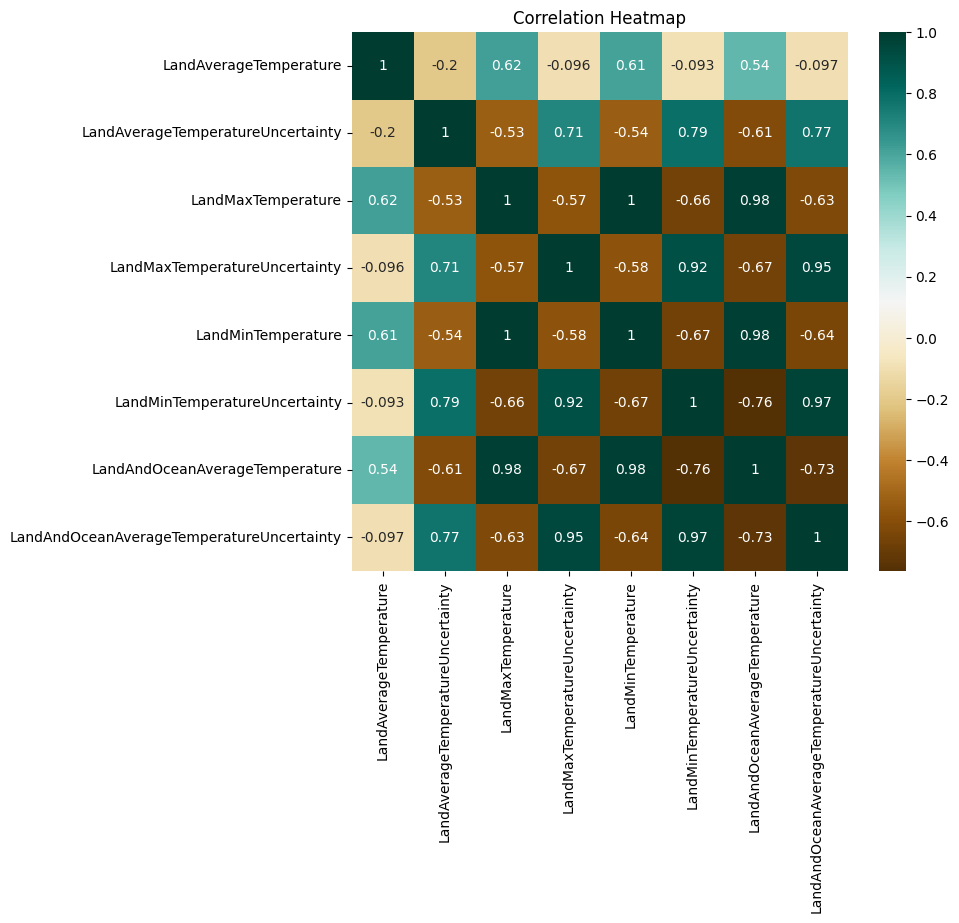

In [61]:
plt.figure(figsize=(8,7))
sns.heatmap(num_col.corr(), annot=True,cmap='BrBG')
plt.title("Correlation Heatmap")
plt.show()


In [62]:
datadict

,DataType,MissingVal,NUnique,Count
dt,object,0,3192,3192
LandAverageTemperature,float64,0,2839,3192
LandAverageTemperatureUncertainty,float64,0,1594,3192
LandMaxTemperature,float64,0,1814,3192
LandMaxTemperatureUncertainty,float64,0,841,3192
LandMinTemperature,float64,0,1873,3192
LandMinTemperatureUncertainty,float64,0,781,3192
LandAndOceanAverageTemperature,float64,0,1596,3192
LandAndOceanAverageTemperatureUncertainty,float64,0,294,3192


In [63]:
from sklearn.preprocessing import LabelEncoder

In [64]:
le=LabelEncoder()
df['dt']=le.fit_transform(df['dt'])
df

,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,0,3.034,3.312625,8.242,1.738,-3.206,2.822,12.833,0.367
1,1,3.083,3.312625,8.242,1.738,-3.206,2.822,12.833,0.367
2,2,5.626,3.076000,8.242,1.738,-3.206,2.822,12.833,0.367
3,3,8.490,2.451000,8.242,1.738,-3.206,2.822,12.833,0.367
4,4,11.573,2.072000,8.242,1.738,-3.206,2.822,12.833,0.367
...,...,...,...,...,...,...,...,...,...
3187,3187,14.755,0.072000,20.699,0.110,9.005,0.170,17.589,0.057
3188,3188,12.999,0.079000,18.845,0.088,7.199,0.229,17.049,0.058
3189,3189,10.801,0.102000,16.450,0.059,5.232,0.115,16.290,0.062
3190,3190,7.433,0.119000,12.892,0.093,2.157,0.106,15.252,0.063


In [65]:
df.columns

Index(['dt', 'LandAverageTemperature', 'LandAverageTemperatureUncertainty',
       'LandMaxTemperature', 'LandMaxTemperatureUncertainty',
       'LandMinTemperature', 'LandMinTemperatureUncertainty',
       'LandAndOceanAverageTemperature',
       'LandAndOceanAverageTemperatureUncertainty'],
      dtype='object')

In [66]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
cols=['dt', 'LandAverageTemperatureUncertainty',
       'LandMaxTemperature', 'LandMaxTemperatureUncertainty',
       'LandMinTemperature', 'LandMinTemperatureUncertainty',
       'LandAndOceanAverageTemperature',
       'LandAndOceanAverageTemperatureUncertainty']
for i in cols:
    df[i]=sc.fit_transform(df[[i]])

In [67]:
sd=sc.fit_transform(df[cols])

In [68]:
df[['dt', 'LandAverageTemperatureUncertainty',
       'LandMaxTemperature', 'LandMaxTemperatureUncertainty',
       'LandMinTemperature', 'LandMinTemperatureUncertainty',
       'LandAndOceanAverageTemperature',
       'LandAndOceanAverageTemperatureUncertainty']]=pd.DataFrame(sd,columns=cols)

In [69]:
df

,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,-1.731508,3.034,2.483602,-0.845286,1.029339,-0.850071,1.232657,-0.970568,1.150933
1,-1.730423,3.083,2.483602,-0.845286,1.029339,-0.850071,1.232657,-0.970568,1.150933
2,-1.729338,5.626,2.239677,-0.845286,1.029339,-0.850071,1.232657,-0.970568,1.150933
3,-1.728253,8.490,1.595396,-0.845286,1.029339,-0.850071,1.232657,-0.970568,1.150933
4,-1.727167,11.573,1.204704,-0.845286,1.029339,-0.850071,1.232657,-0.970568,1.150933
...,...,...,...,...,...,...,...,...,...
3187,1.727167,14.755,-0.856996,1.916875,-1.104265,1.945641,-0.958956,2.137881,-1.246549
3188,1.728253,12.999,-0.849780,1.505777,-1.133097,1.532157,-0.910199,1.784945,-1.238815
3189,1.729338,10.801,-0.826071,0.974720,-1.171104,1.081812,-1.004409,1.288874,-1.207880
3190,1.730423,7.433,-0.808546,0.185785,-1.126544,0.377790,-1.011846,0.610453,-1.200146


In [70]:
x=df.drop('LandAverageTemperature',axis=1)
x

,dt,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,-1.731508,2.483602,-0.845286,1.029339,-0.850071,1.232657,-0.970568,1.150933
1,-1.730423,2.483602,-0.845286,1.029339,-0.850071,1.232657,-0.970568,1.150933
2,-1.729338,2.239677,-0.845286,1.029339,-0.850071,1.232657,-0.970568,1.150933
3,-1.728253,1.595396,-0.845286,1.029339,-0.850071,1.232657,-0.970568,1.150933
4,-1.727167,1.204704,-0.845286,1.029339,-0.850071,1.232657,-0.970568,1.150933
...,...,...,...,...,...,...,...,...
3187,1.727167,-0.856996,1.916875,-1.104265,1.945641,-0.958956,2.137881,-1.246549
3188,1.728253,-0.849780,1.505777,-1.133097,1.532157,-0.910199,1.784945,-1.238815
3189,1.729338,-0.826071,0.974720,-1.171104,1.081812,-1.004409,1.288874,-1.207880
3190,1.730423,-0.808546,0.185785,-1.126544,0.377790,-1.011846,0.610453,-1.200146


In [71]:
y=df['LandAverageTemperature']
y

0        3.034
1        3.083
2        5.626
3        8.490
4       11.573
         ...  
3187    14.755
3188    12.999
3189    10.801
3190     7.433
3191     5.518
Name: LandAverageTemperature, Length: 3192, dtype: float64

In [72]:
from sklearn.model_selection import train_test_split


In [73]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [74]:
from sklearn.linear_model import  LinearRegression
reg_model=LinearRegression()

In [75]:
reg_model=reg_model.fit(x_train,y_train)
y_reg=reg_model.predict(x_test)

In [76]:
from sklearn.metrics import r2_score

In [77]:
r2=r2_score(y_test,y_reg)
r2

0.6320944490613268

In [78]:
new_data=[[-1.731508,2.483602,-0.845286,1.029339,-0.850071,1.232657,-0.970568,1.150933]]
prediction=reg_model.predict(new_data)
prediction

array([5.88114695])

In [79]:
from sklearn.ensemble import RandomForestRegressor
model2= RandomForestRegressor(n_estimators=100, random_state=42)

In [80]:
model2=model2.fit(x_train,y_train)

In [83]:
y_pred2=model2.predict(x_test)
r2_2 = r2_score(y_test,y_pred2)

In [84]:
r2_2

0.7219054139532352

In [85]:
from sklearn.tree import DecisionTreeRegressor
model_dt= DecisionTreeRegressor(criterion='squared_error',random_state=42)

In [86]:
model_dt=model_dt.fit(x_train,y_train)
y_pred_dt=model_dt.predict(x_test)
r2_dt=r2_score(y_test,y_pred_dt)
r2_dt

0.558160359706211

In [90]:
from sklearn.svm import SVR
svr_lin=SVR(kernel="linear")

In [91]:
svr_lin.fit(x_train,y_train)


,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [92]:
y_lin=svr_lin.predict(x_test)
r2_lin=r2_score(y_test,y_lin)
r2_lin


0.5912662913961039

In [93]:
svr_rbf=SVR(kernel="rbf")
svr_rbf.fit(x_train,y_train)
y_rbf=svr_rbf.predict(x_test)
r2_rbf=r2_score(y_test,y_rbf)
r2_rbf

0.6789242184965927

In [106]:
from sklearn.neighbors import KNeighborsRegressor
metric_k=[]
neighbours=range(3,15)

In [107]:
for k in neighbours:
    knn=KNeighborsRegressor(n_neighbors=k,metric='euclidean')
    knn.fit(x_train,y_train)
    y_preds=knn.predict(x_test)
    r2_sc=r2_score(y_test,y_preds)
    metric_k.append(r2_sc)

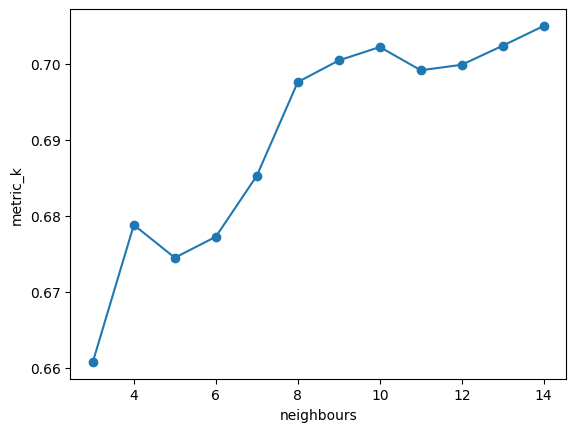

In [108]:
plt.plot(neighbours,metric_k,'o-')
plt.xlabel("neighbours")
plt.ylabel("metric_k")
plt.show()

In [ ]:
knn=KNeighborsRegressor(n_neighbors=14,metric="euclidean")
knn.fit(x_train,y_train)
y_predk=knn.predict(x_test)
r2_k=r2_score(y_test,y_predk)
r2_k

0.703784619954881

In [109]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)

In [112]:
ridge_model.fit(x_train,y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [114]:
y_ridge=ridge_model.predict(x_test)
r2_ridge=r2_score(y_test,y_ridge)
r2_ridge

0.6318259246260174

In [115]:
prediction_ridge=ridge_model.predict(new_data)
prediction_ridge

array([5.86834325])

In [116]:
from sklearn.linear_model import Lasso
lasso_model=Lasso(alpha=0.1)

In [117]:
lasso_model.fit(x_train,y_train)
y_lasso=lasso_model.predict(x_test)
r2_lasso=r2_score(y_test,y_lasso)
r2_lasso

0.5896824459331833

In [118]:
from xgboost import XGBRegressor
xgb_model=XGBRegressor()

In [119]:
xgb_model.fit(x_train,y_train)
y_xgb=xgb_model.predict(x_test)
r2_xgb=r2_score(y_test,y_xgb)
r2_xgb

0.6843164224441616

In [120]:
from catboost import CatBoostRegressor
cat_model=CatBoostRegressor()


In [121]:
cat_model.fit(x_train,y_train)
y_cat=cat_model.predict(x_test)
r2_cat=r2_score(y_test,y_cat)
r2_cat

Learning rate set to 0.046998
0:	learn: 4.2516897	total: 145ms	remaining: 2m 24s
1:	learn: 4.1427393	total: 148ms	remaining: 1m 13s
2:	learn: 4.0493575	total: 151ms	remaining: 50.1s
3:	learn: 3.9535935	total: 155ms	remaining: 38.5s
4:	learn: 3.8633399	total: 157ms	remaining: 31.3s
5:	learn: 3.7750857	total: 160ms	remaining: 26.5s
6:	learn: 3.7002790	total: 163ms	remaining: 23.1s
7:	learn: 3.6329198	total: 166ms	remaining: 20.6s
8:	learn: 3.5643666	total: 169ms	remaining: 18.6s
9:	learn: 3.5041477	total: 173ms	remaining: 17.2s
10:	learn: 3.4430853	total: 177ms	remaining: 15.9s
11:	learn: 3.3819629	total: 180ms	remaining: 14.8s
12:	learn: 3.3236238	total: 183ms	remaining: 13.9s
13:	learn: 3.2666090	total: 187ms	remaining: 13.2s
14:	learn: 3.2145587	total: 191ms	remaining: 12.5s
15:	learn: 3.1653857	total: 194ms	remaining: 11.9s
16:	learn: 3.1273546	total: 196ms	remaining: 11.4s
17:	learn: 3.0856136	total: 200ms	remaining: 10.9s
18:	learn: 3.0434972	total: 202ms	remaining: 10.5s
19:	learn

0.7033184530096004

In [123]:
import lightgbm as lgb
lgb_model=lgb.LGBMRegressor()

In [124]:
lgb_model.fit(x_train,y_train)
y_lgb=lgb_model.predict(x_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000164 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1894
[LightGBM] [Info] Number of data points in the train set: 2394, number of used features: 8
[LightGBM] [Info] Start training from score 8.315330


In [125]:
r2_lgb=r2_score(y_test,y_lgb)
r2_lgb

0.6874501536106832